INFO:tcga_classifier.data_loader:Gene expression matrix loaded: 801 samples, 20531 genes
INFO:tcga_classifier.data_loader:Loading labels from: ../data/labels.csv
INFO:tcga_classifier.data_loader:Labels loaded: 801 samples
INFO:tcga_classifier.data_loader:Class distribution:
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
INFO:tcga_classifier.preprocessor:Splitting data: 80% train, 20% test
INFO:tcga_classifier.preprocessor:Training set: 640 samples
INFO:tcga_classifier.preprocessor:Test set: 161 samples
INFO:tcga_classifier.preprocessor:Training class distribution:
Class
BRCA    240
KIRC    116
LUAD    113
PRAD    109
COAD     62
INFO:tcga_classifier.preprocessor:Fitting StandardScaler on training data
INFO:tcga_classifier.preprocessor:Feature scaling complete
INFO:tcga_classifier.preprocessor:Training data mean after scaling: -0.0000 (should be ~0)
INFO:tcga_classifier.preprocessor:Training data std after scaling: 0.9932 (should be ~1)


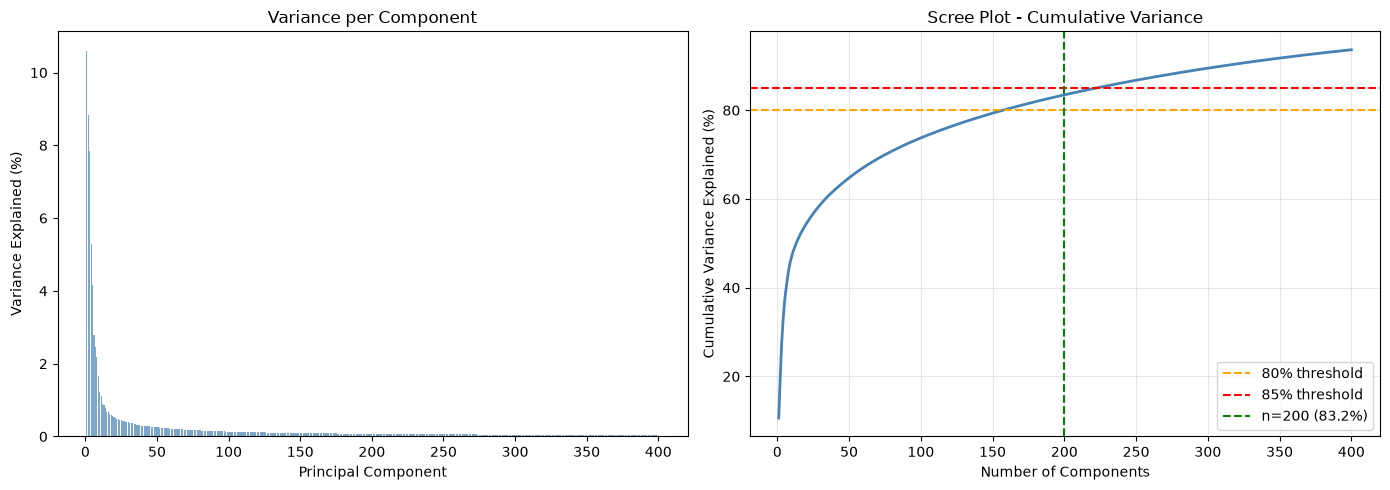

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tcga_classifier.data_loader import load_data
from tcga_classifier.preprocessor import split_data, scale_features

# Load and preprocess
X, y = load_data("../data/data.csv", "../data/labels.csv")
X_train, X_test, y_train, y_test = split_data(X, y)
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)

# Fit PCA with enough components to see the full curve
from sklearn.decomposition import PCA
pca_full = PCA(n_components=400, random_state=42)
pca_full.fit(X_train_scaled)

# Cumulative variance explained
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_) * 100

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot - individual variance per component
ax1.bar(range(1, 401), pca_full.explained_variance_ratio_ * 100, alpha=0.7, color="steelblue")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Variance Explained (%)")
ax1.set_title("Variance per Component")

# Right plot - cumulative variance
ax2.plot(range(1, 401), cumulative_variance, color="steelblue", linewidth=2)
ax2.axhline(y=80, color="orange", linestyle="--", label="80% threshold")
ax2.axhline(y=85, color="red", linestyle="--", label="85% threshold")
ax2.axvline(x=200, color="green", linestyle="--", label="n=200 (83.2%)")
ax2.set_xlabel("Number of Components")
ax2.set_ylabel("Cumulative Variance Explained (%)")
ax2.set_title("Scree Plot - Cumulative Variance")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("scree_plot.png", dpi=150)
plt.show()

INFO:tcga_classifier.preprocessor:Fitting PCA with 160 components on training data
INFO:tcga_classifier.preprocessor:PCA complete: 160 components retain 80.0% of variance
INFO:tcga_classifier.preprocessor:Training shape after PCA: (640, 160)
INFO:tcga_classifier.preprocessor:Test shape after PCA: (161, 160)


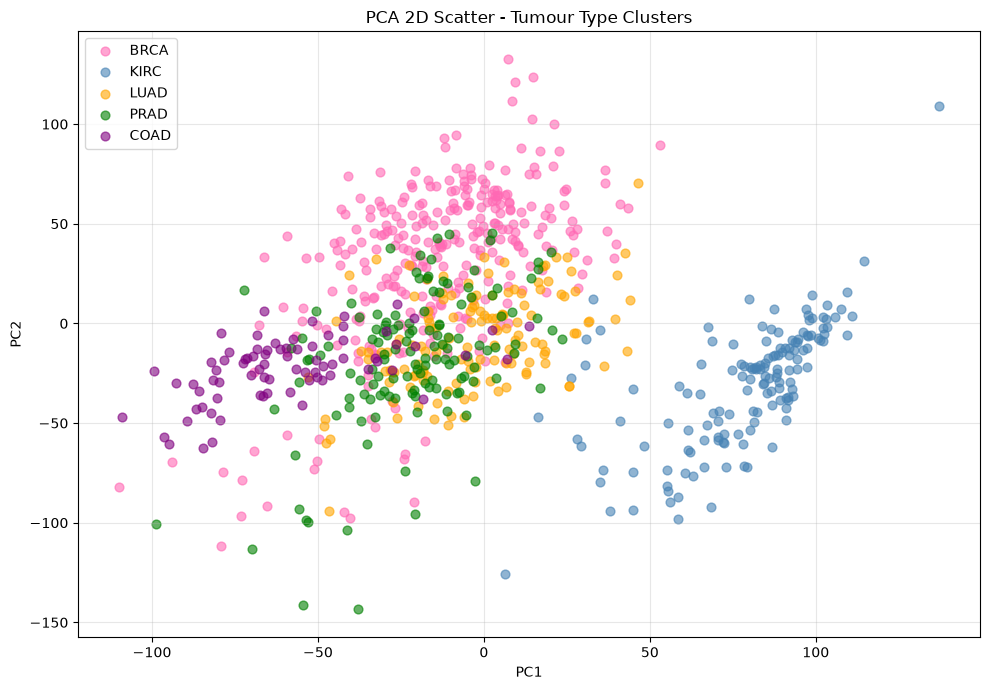

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# PCA 2D scatter plot
from tcga_classifier.preprocessor import apply_pca

X_train_pca, X_test_pca, pca = apply_pca(X_train_scaled, X_test_scaled, n_components=160)

# Combine train and test back together for plotting
import numpy as np
import pandas as pd

X_pca_all = np.vstack([X_train_pca, X_test_pca])
y_all = pd.concat([y_train, y_test])

# Colour map for each tumour type
colours = {
    "BRCA": "hotpink",
    "KIRC": "steelblue",
    "LUAD": "orange",
    "PRAD": "green",
    "COAD": "purple"
}

plt.figure(figsize=(10, 7))

for tumour_type, colour in colours.items():
    mask = y_all == tumour_type
    plt.scatter(
        X_pca_all[mask, 0],   # PC1 scores
        X_pca_all[mask, 1],   # PC2 scores
        c=colour,
        label=tumour_type,
        alpha=0.6,
        s=40
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Scatter - Tumour Type Clusters")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pca_scatter.png", dpi=150)
plt.show()